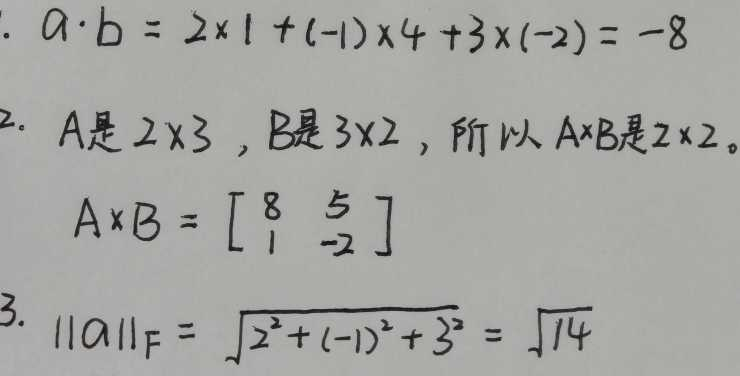

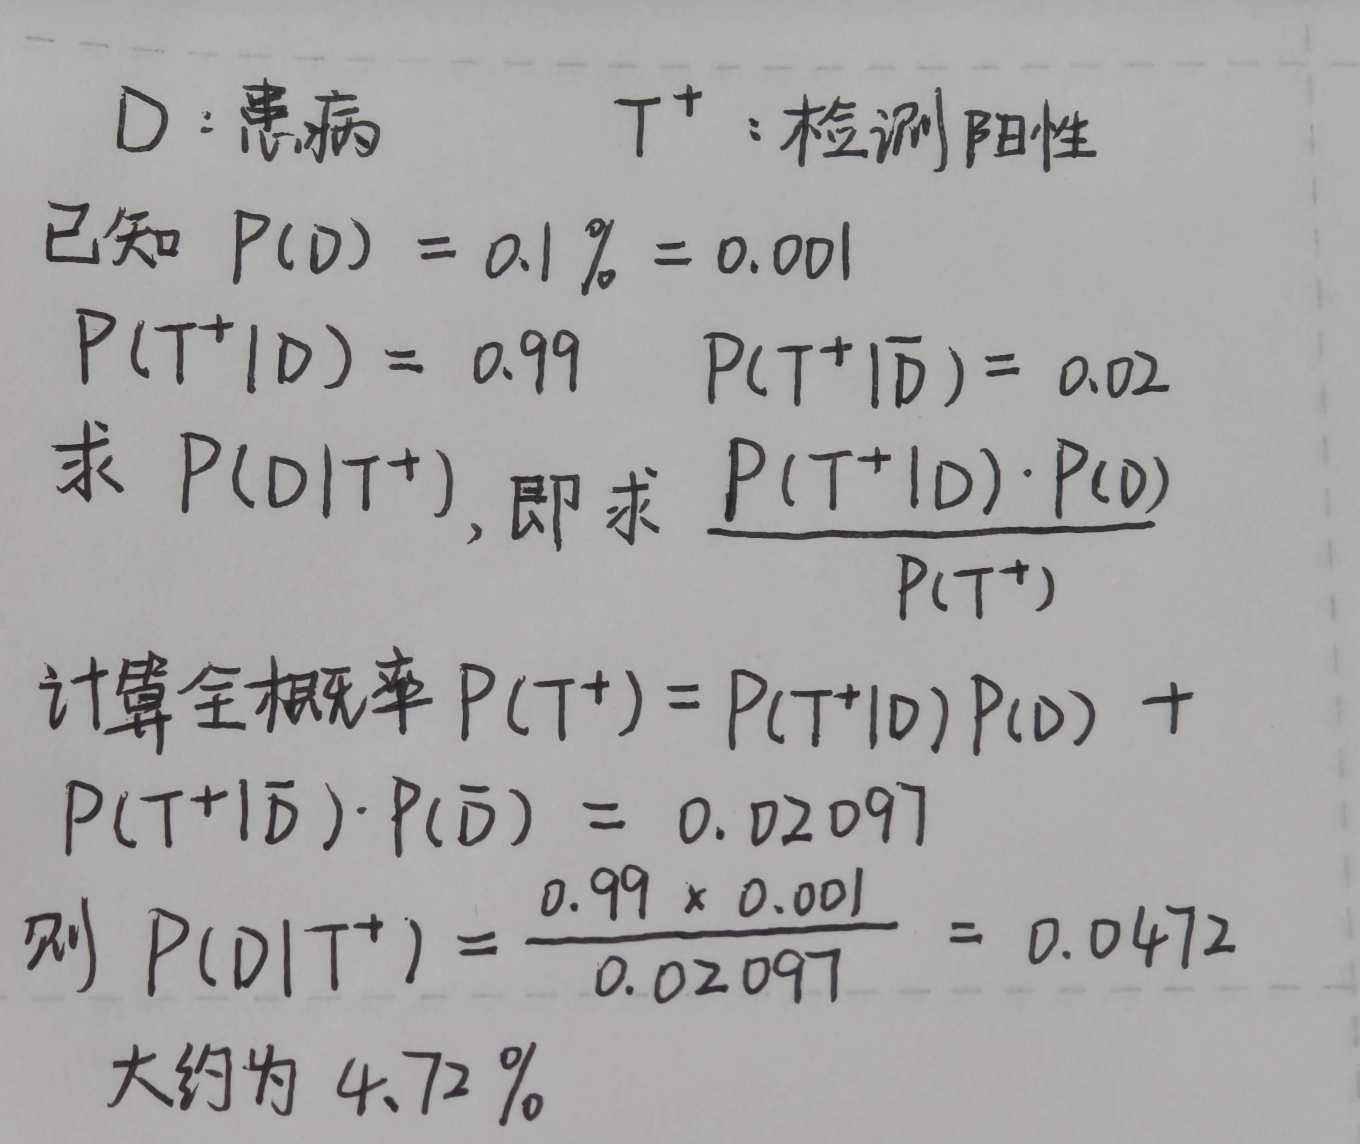

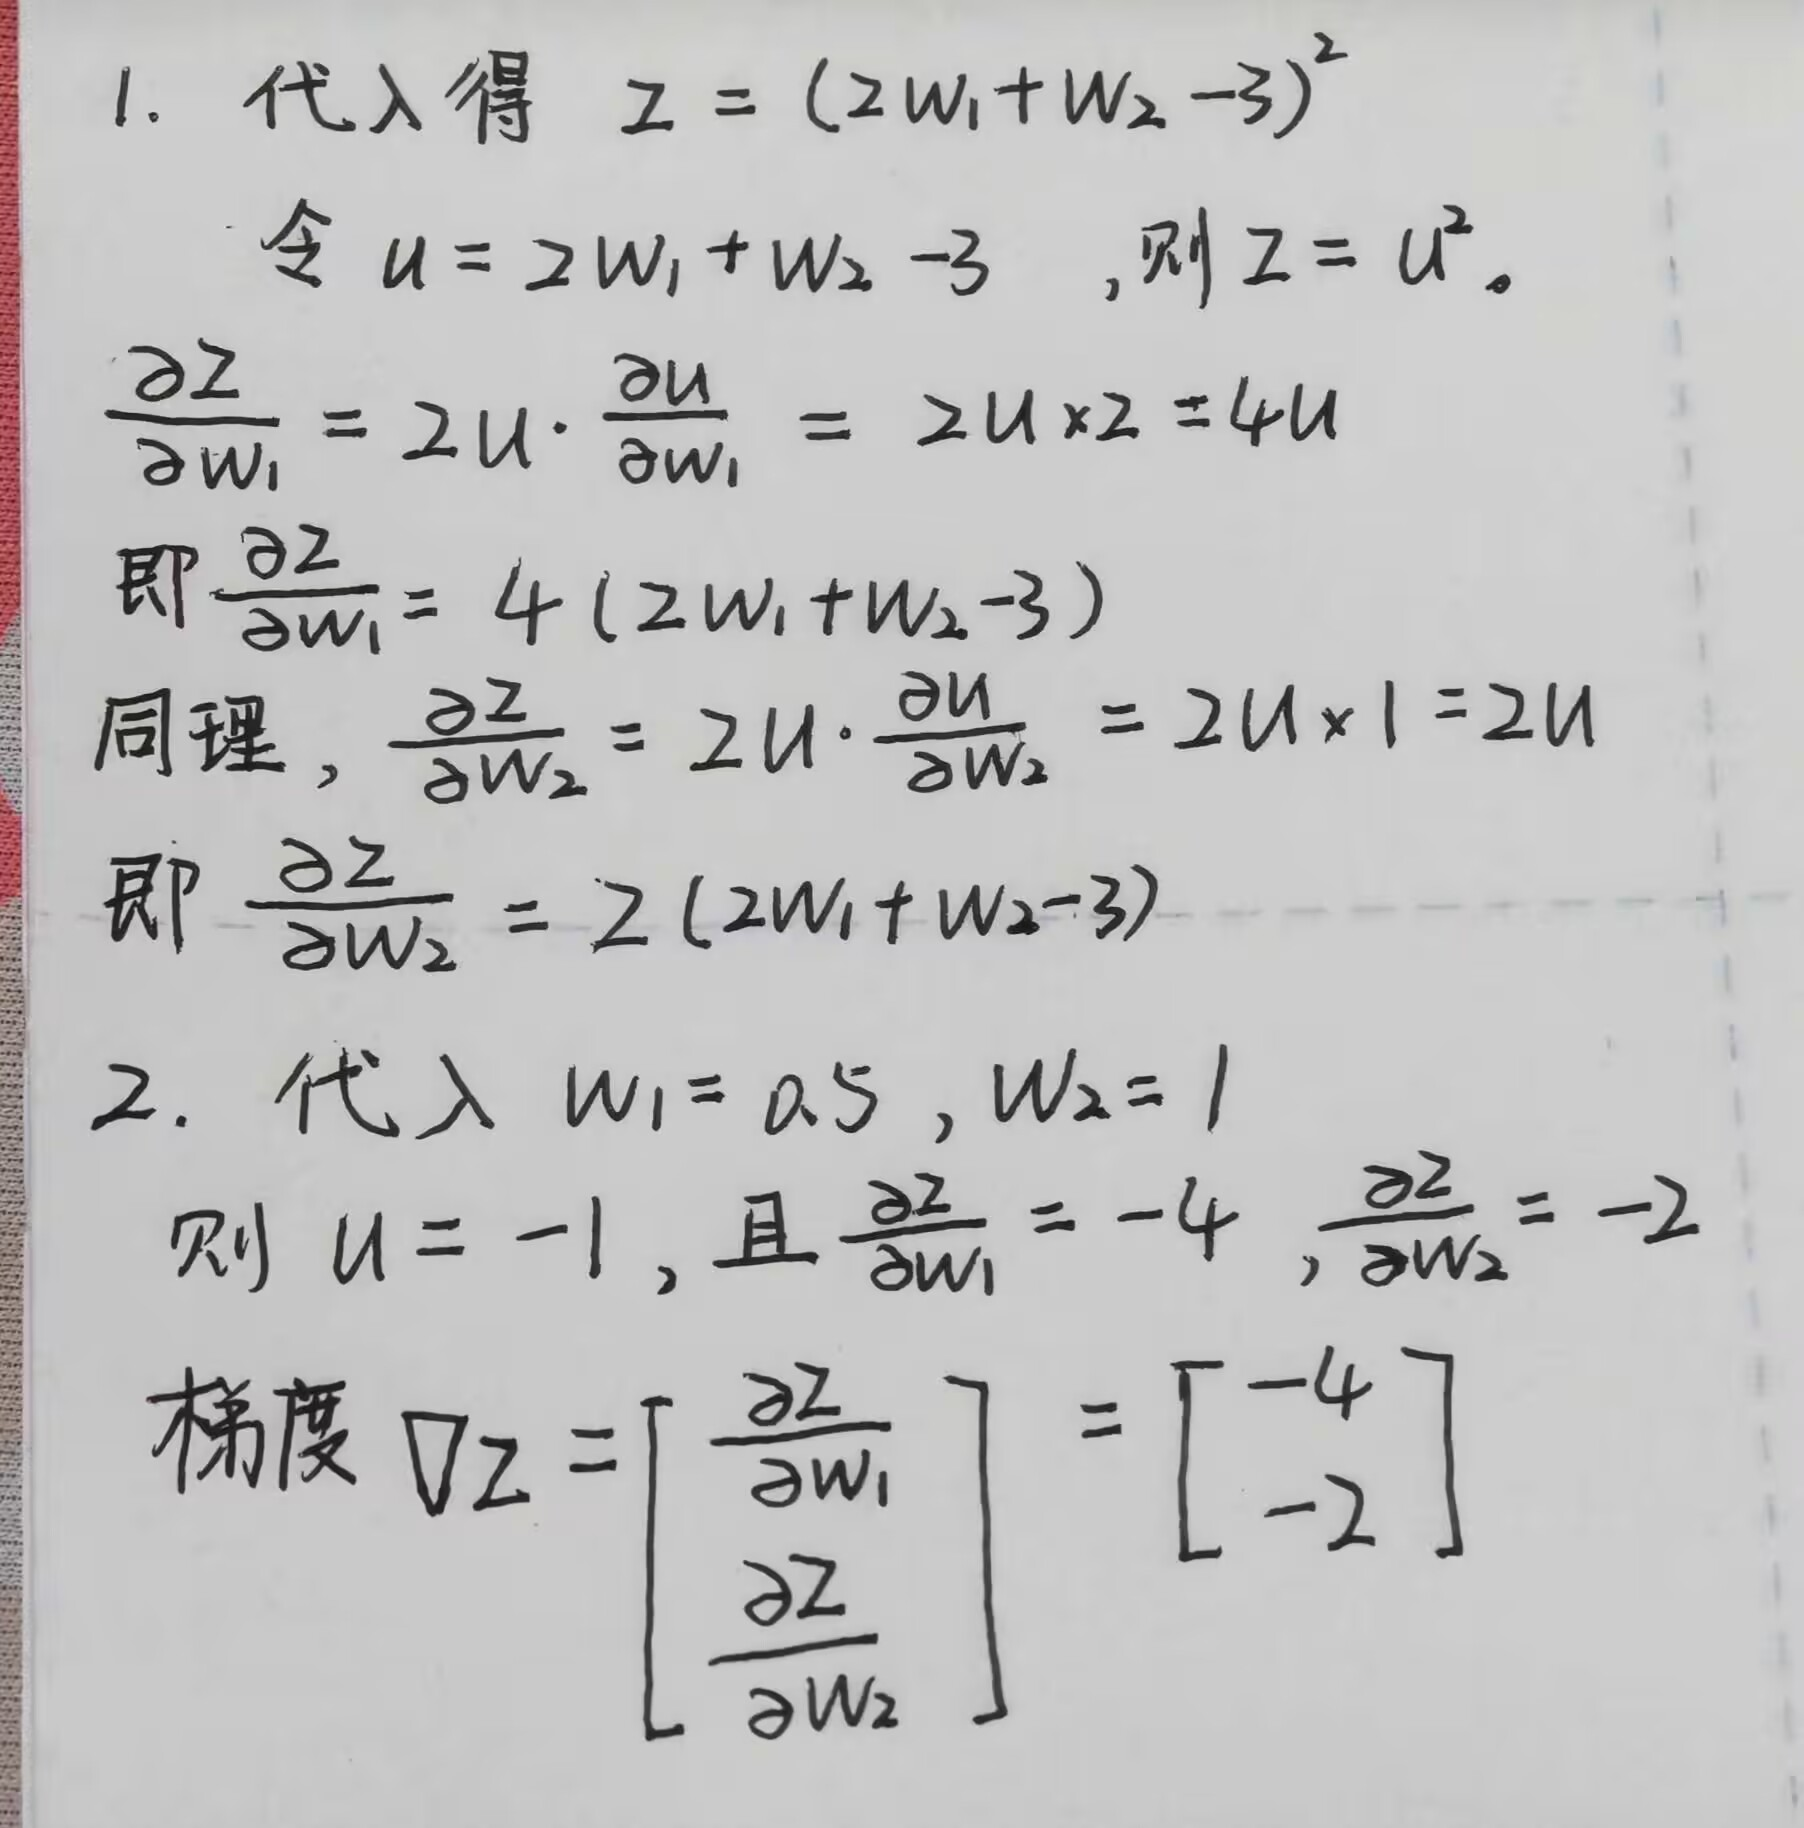

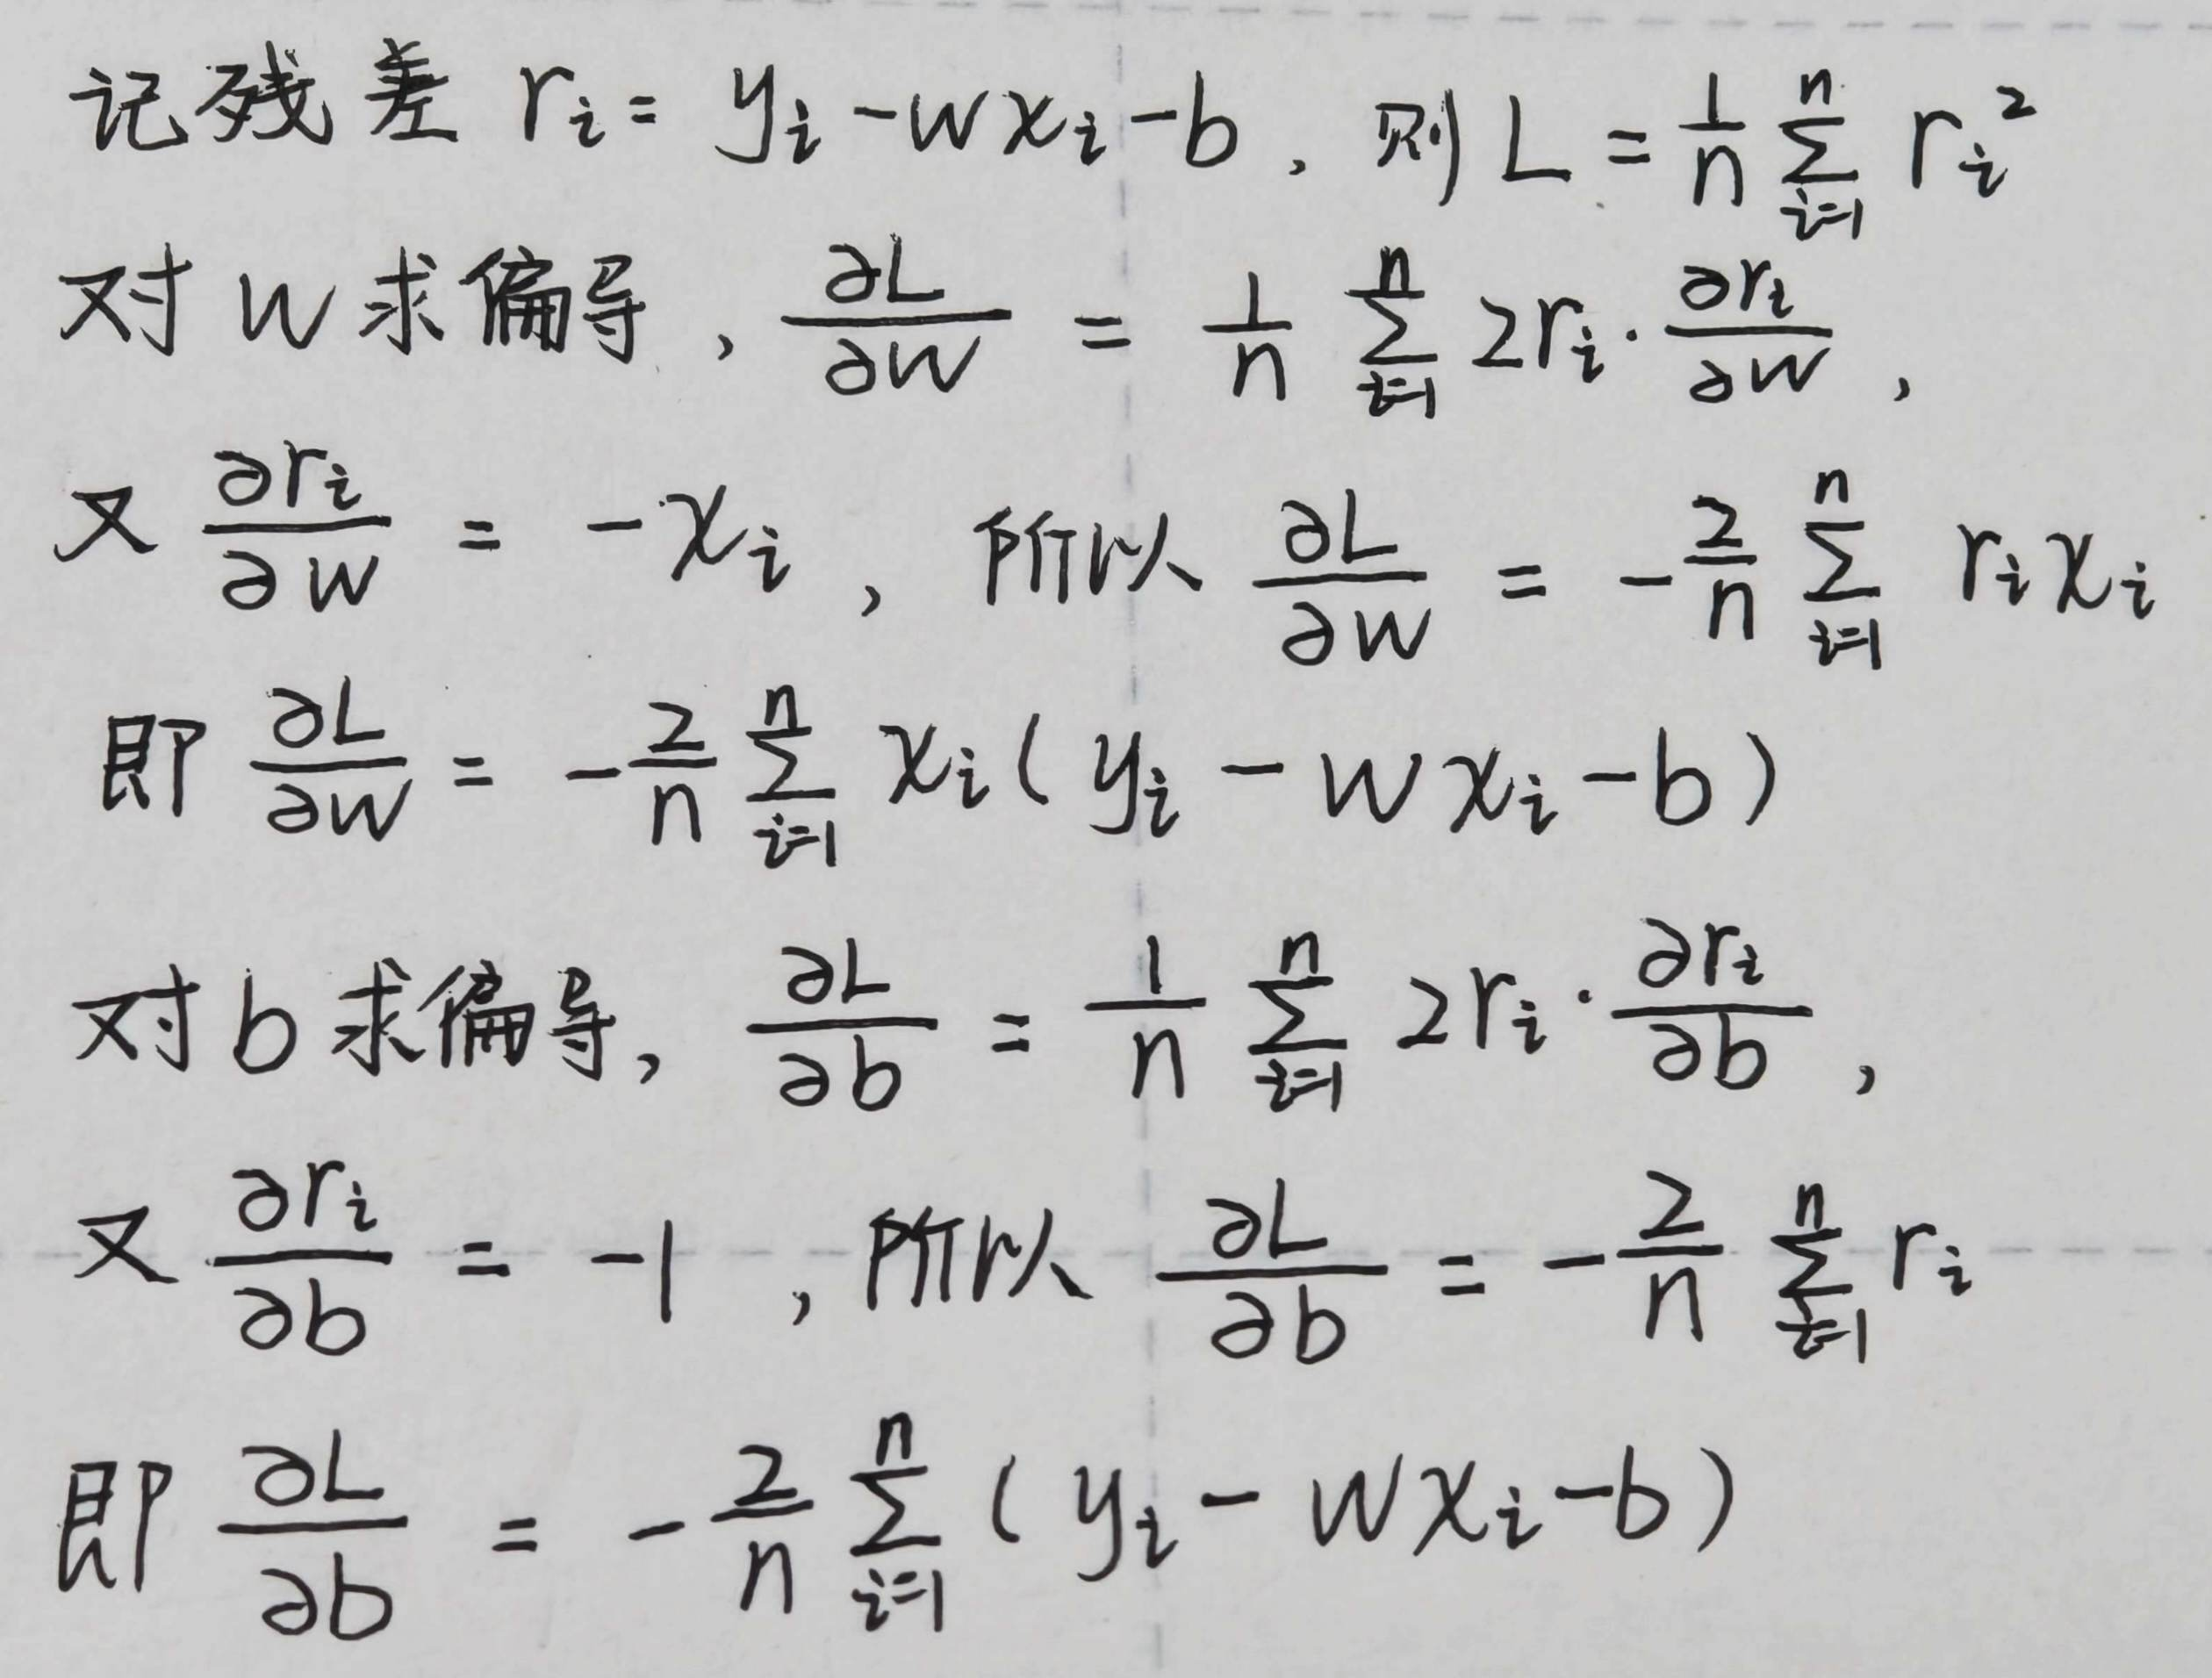

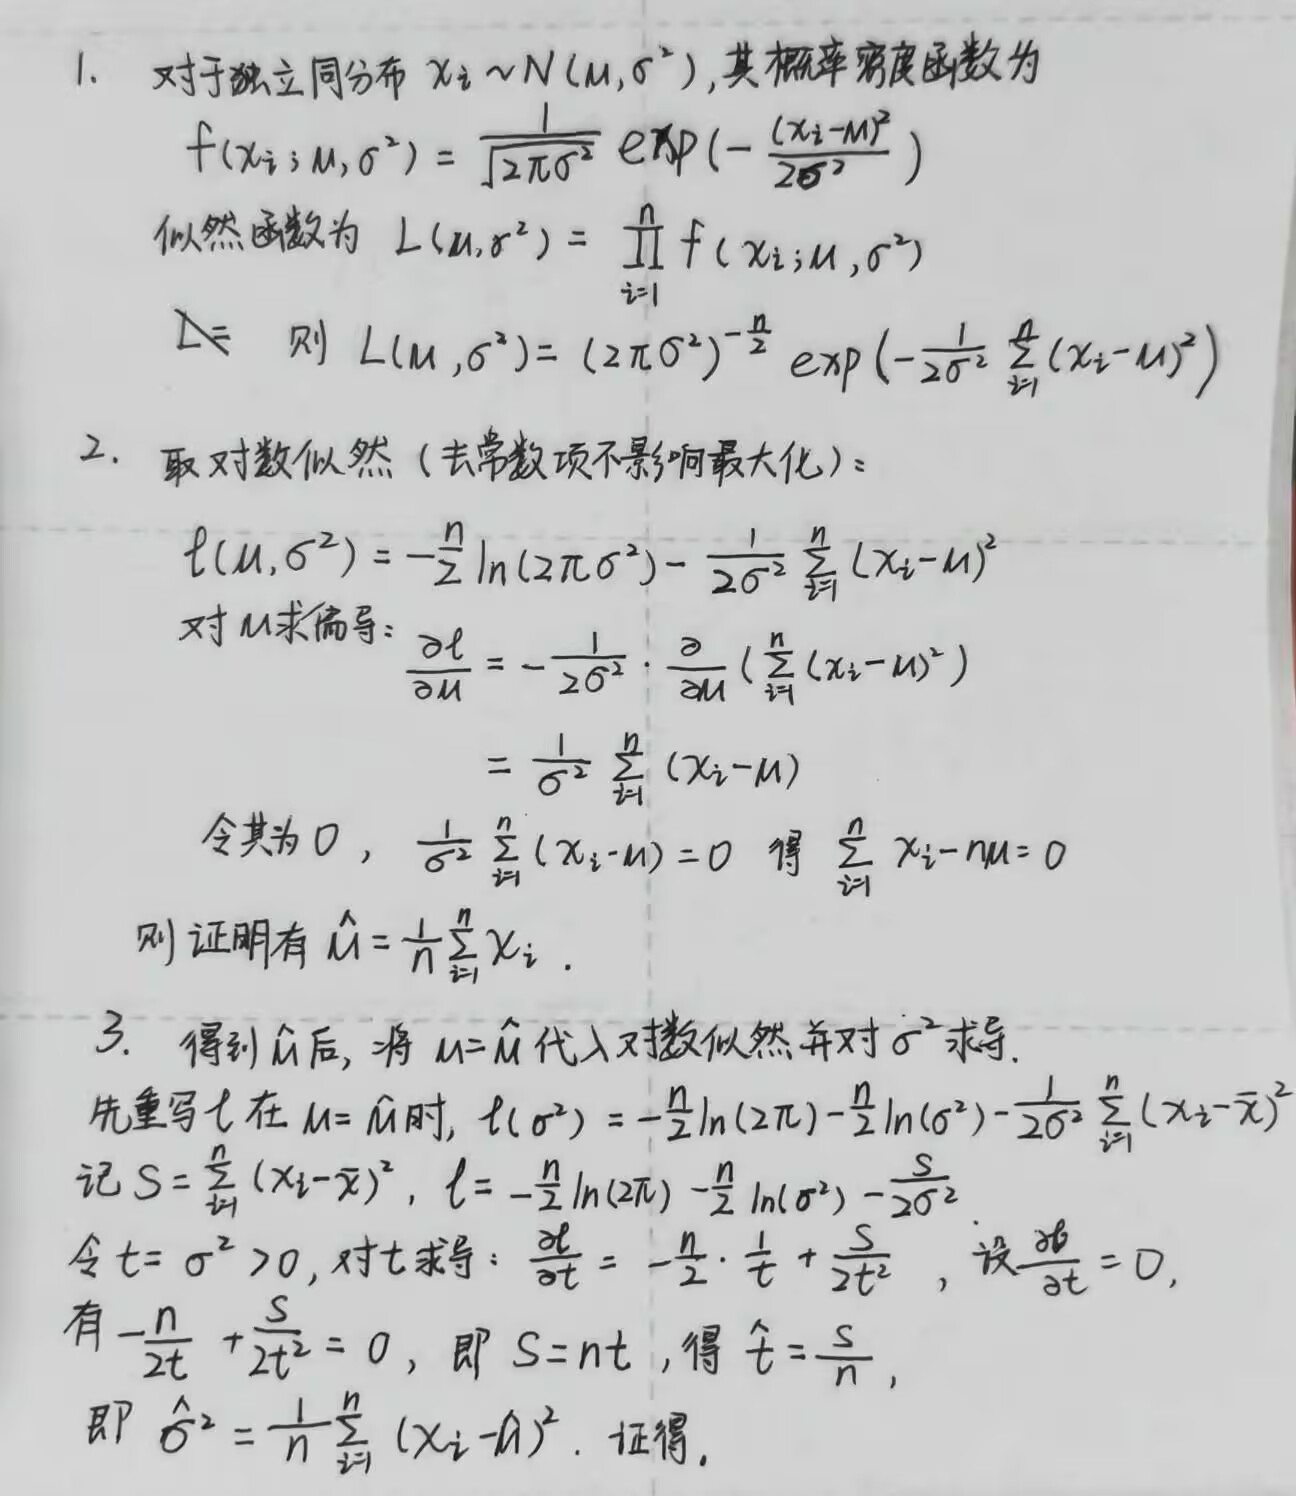

2.2.编程题

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import torch
import torch.nn.functional as F

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


In [39]:
# 1. 创建一个形状为 3×4 的随机矩阵 X，元素服从标准正态分布
np.random.seed(42)  # 设置随机种子保证可重复性
X = np.random.randn(3, 4)
print(f"1. 随机矩阵 X (3*4):\n{X}\n")

# 2. 创建一个形状为 4×2 的全1矩阵 Y
Y = np.ones((4, 2))
print(f"2. 全1矩阵 Y (4*2):\n{Y}\n")

# 3. 计算矩阵乘法 Z = X × Y
Z = np.dot(X, Y)
print(f"3. 矩阵乘法 Z = X * Y (3*2):\n{Z}\n")

# 4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第2行所有元素
print(f"4. Z的第一行第二列元素: {Z[0, 1]}")
print(f"   Z的第2行所有元素: {Z[1, :]}\n")

# 5. 计算 Z 的 Frobenius 范数
frobenius_norm = np.linalg.norm(Z, 'fro')
print(f"5. Z的Frobenius范数: {frobenius_norm:.6f}")

1. 随机矩阵 X (3*4):
[[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]

2. 全1矩阵 Y (4*2):
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

3. 矩阵乘法 Z = X * Y (3*2):
[[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]

4. Z的第一行第二列元素: 2.5291682463487657
   Z的第2行所有元素: [1.87835721 1.87835721]

5. Z的Frobenius范数: 4.616873


3.2编程题

C:\Users\liang\AppData\Local\Temp\ipykernel_41052\1490565331.py:35: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()


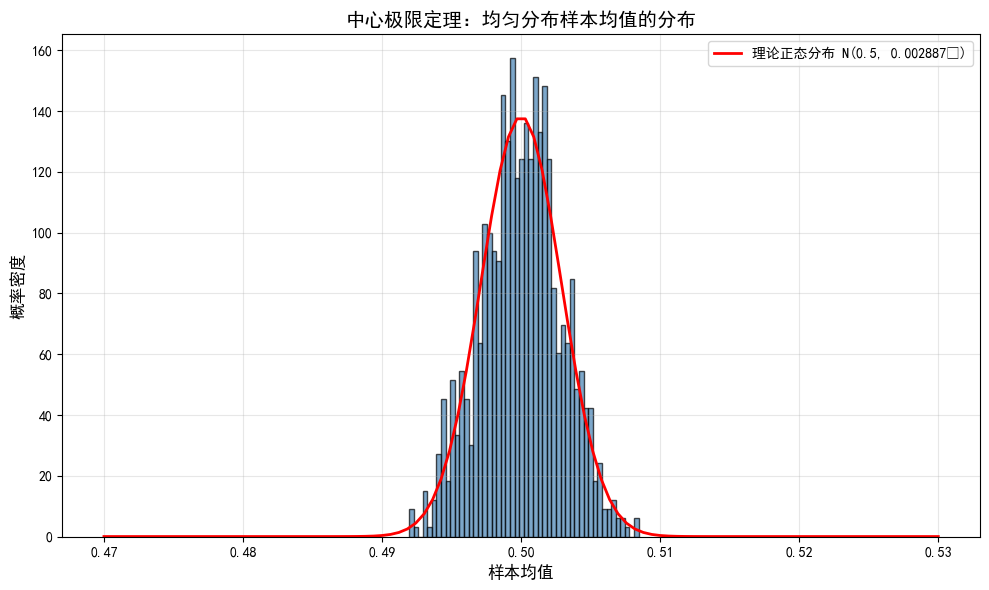

   实际方差: 0.00000828
   理论方差: 0.00000833
   误差: 0.00000006


In [40]:
# 参数设置
n = 10000  # 每次抽样的样本数
m = 1000   # 重复次数

# 1. 生成m次抽样，每次抽取n个U(0,1)分布的随机变量，计算均值
np.random.seed(42)
sample_means = []

for i in range(m):
    samples = np.random.uniform(0, 1, n)
    sample_means.append(np.mean(samples))

sample_means = np.array(sample_means)

# 2. 绘制直方图和理论正态分布曲线
fig, ax = plt.subplots(figsize=(10, 6))

# 绘制直方图
count, bins, patches = ax.hist(sample_means, bins=50, density=True, 
                                alpha=0.7, color='steelblue', edgecolor='black')

# 理论正态分布：均值=0.5，方差=(1/12)/n
theoretical_mean = 0.5
theoretical_std = np.sqrt(1/12 / n)
x = np.linspace(0.47, 0.53, 100)
y = stats.norm.pdf(x, theoretical_mean, theoretical_std)
ax.plot(x, y, 'r-', linewidth=2, label=f'理论正态分布 N({theoretical_mean}, {theoretical_std:.6f}²)')

ax.set_xlabel('样本均值', fontsize=12)
ax.set_ylabel('概率密度', fontsize=12)
ax.set_title('中心极限定理：均匀分布样本均值的分布', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('clt_demo.png', dpi=150)
plt.show()

# 3. 计算这些均值的实际方差
actual_variance = np.var(sample_means)
theoretical_variance = 1/12 / n
print(f"   实际方差: {actual_variance:.8f}")
print(f"   理论方差: {theoretical_variance:.8f}")
print(f"   误差: {abs(actual_variance - theoretical_variance):.8f}")

4.2编程题

In [41]:
# 定义前向计算
def forward(x, w1, w2):
    a = x * w1
    b = a + w2
    L = b ** 2
    return L, a, b

# 手动计算梯度（链式法则）
def manual_gradients(x, w1, w2):
    # 前向传播
    a = x * w1
    b = a + w2
    L = b ** 2
    
    # 反向传播
    dL_db = 2 * b           # dL/db
    db_da = 1               # db/da
    db_dw2 = 1              # db/dw2
    da_dw1 = x              # da/dw1
    
    dL_dw1 = dL_db * db_da * da_dw1  # dL/dw1 = dL/db * db/da * da/dw1
    dL_dw2 = dL_db * db_dw2          # dL/dw2 = dL/db * db/dw2
    
    return dL_dw1, dL_dw2

# 给定参数
x = 2.0
w1 = 1.5
w2 = 0.5

# 前向计算
L, a, b = forward(x, w1, w2)
print(f"1. 前向计算结果:")
print(f"   L = b² = {b}² = {L}")

# 手动计算梯度
dw1_manual, dw2_manual = manual_gradients(x, w1, w2)
print(f"\n2. 手动计算的梯度:")
print(f"   ∂L/∂w1 = {dw1_manual}")
print(f"   ∂L/∂w2 = {dw2_manual}")

# 使用PyTorch验证
w1_t = torch.tensor(w1, requires_grad=True)
w2_t = torch.tensor(w2, requires_grad=True)
x_t = torch.tensor(x)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2

L_t.backward()

print(f"\n3. PyTorch自动计算的梯度:")
print(f"   ∂L/∂w1 = {w1_t.grad.item()}")
print(f"   ∂L/∂w2 = {w2_t.grad.item()}")

# 验证一致性
print(f"\n4. 验证结果:")
print(f"   w1梯度一致: {abs(dw1_manual - w1_t.grad.item()) < 1e-6}")
print(f"   w2梯度一致: {abs(dw2_manual - w2_t.grad.item()) < 1e-6}")

1. 前向计算结果:
   L = b² = 3.5² = 12.25

2. 手动计算的梯度:
   ∂L/∂w1 = 14.0
   ∂L/∂w2 = 7.0

3. PyTorch自动计算的梯度:
   ∂L/∂w1 = 14.0
   ∂L/∂w2 = 7.0

4. 验证结果:
   w1梯度一致: True
   w2梯度一致: True


5.2编程题

In [42]:
# 加载数据
digits = load_digits()
X = digits.data  # 64维特征
y = digits.target  # 0-9的标签

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 数据标准化
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
std[std == 0] = 1
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# One-hot编码
def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]

y_train_onehot = one_hot(y_train)
y_test_onehot = one_hot(y_test)

# Softmax函数
def softmax(logits):
    exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

# 交叉熵损失
def cross_entropy_loss(y_pred, y_true):
    n_samples = y_pred.shape[0]
    loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / n_samples
    return loss

# Softmax回归模型
class SoftmaxRegression:
    def __init__(self, input_dim, num_classes, learning_rate=0.1):
        self.W = np.random.randn(input_dim, num_classes) * 0.01
        self.b = np.zeros(num_classes)
        self.lr = learning_rate
    
    def forward(self, X):
        return softmax(np.dot(X, self.W) + self.b)
    
    def compute_gradients(self, X, y_true, y_pred):
        n_samples = X.shape[0]
        grad_W = np.dot(X.T, (y_pred - y_true)) / n_samples
        grad_b = np.sum(y_pred - y_true, axis=0) / n_samples
        return grad_W, grad_b
    
    def update(self, grad_W, grad_b):
        self.W -= self.lr * grad_W
        self.b -= self.lr * grad_b
    
    def predict(self, X):
        y_pred = self.forward(X)
        return np.argmax(y_pred, axis=1)

# 训练模型
input_dim = X_train.shape[1]
num_classes = 10
batch_size = 32
epochs = 50
learning_rate = 0.1

model = SoftmaxRegression(input_dim, num_classes, learning_rate)

print(f"训练参数: 输入维度={input_dim}, 类别数={num_classes}, 批量大小={batch_size}, 学习率={learning_rate}, 轮数={epochs}")
print("\n开始训练...")

train_losses = []
test_accuracies = []

for epoch in range(epochs):
    # 小批量训练
    indices = np.random.permutation(X_train.shape[0])
    epoch_loss = 0
    num_batches = 0
    
    for i in range(0, X_train.shape[0], batch_size):
        batch_indices = indices[i:i+batch_size]
        X_batch = X_train[batch_indices]
        y_batch = y_train_onehot[batch_indices]
        
        # 前向传播
        y_pred = model.forward(X_batch)
        
        # 计算损失
        loss = cross_entropy_loss(y_pred, y_batch)
        epoch_loss += loss
        num_batches += 1
        
        # 计算梯度并更新
        grad_W, grad_b = model.compute_gradients(X_batch, y_batch, y_pred)
        model.update(grad_W, grad_b)
    
    avg_loss = epoch_loss / num_batches
    train_losses.append(avg_loss)
    
    # 测试准确率
    y_test_pred = model.predict(X_test)
    test_acc = np.mean(y_test_pred == y_test)
    test_accuracies.append(test_acc)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Test Accuracy: {test_acc:.4f}")

# 最终测试准确率
y_test_pred = model.predict(X_test)
final_accuracy = np.mean(y_test_pred == y_test)
print(f"\n最终测试集准确率: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")


训练参数: 输入维度=64, 类别数=10, 批量大小=32, 学习率=0.1, 轮数=50

开始训练...
Epoch 10/50, Loss: 0.1354, Test Accuracy: 0.9639
Epoch 20/50, Loss: 0.0907, Test Accuracy: 0.9694
Epoch 30/50, Loss: 0.0715, Test Accuracy: 0.9722
Epoch 40/50, Loss: 0.0600, Test Accuracy: 0.9722
Epoch 50/50, Loss: 0.0521, Test Accuracy: 0.9750

最终测试集准确率: 0.9750 (97.50%)


6.2编程题

训练集大小: (400, 2), 测试集大小: (200, 2)

开始训练逻辑回归模型...
Iteration 200/1000, Loss: 0.254493
Iteration 400/1000, Loss: 0.222693
Iteration 600/1000, Loss: 0.211820
Iteration 800/1000, Loss: 0.206808
Iteration 1000/1000, Loss: 0.204145

训练集准确率: 0.9100 (91.00%)
测试集准确率: 0.9050 (90.50%)


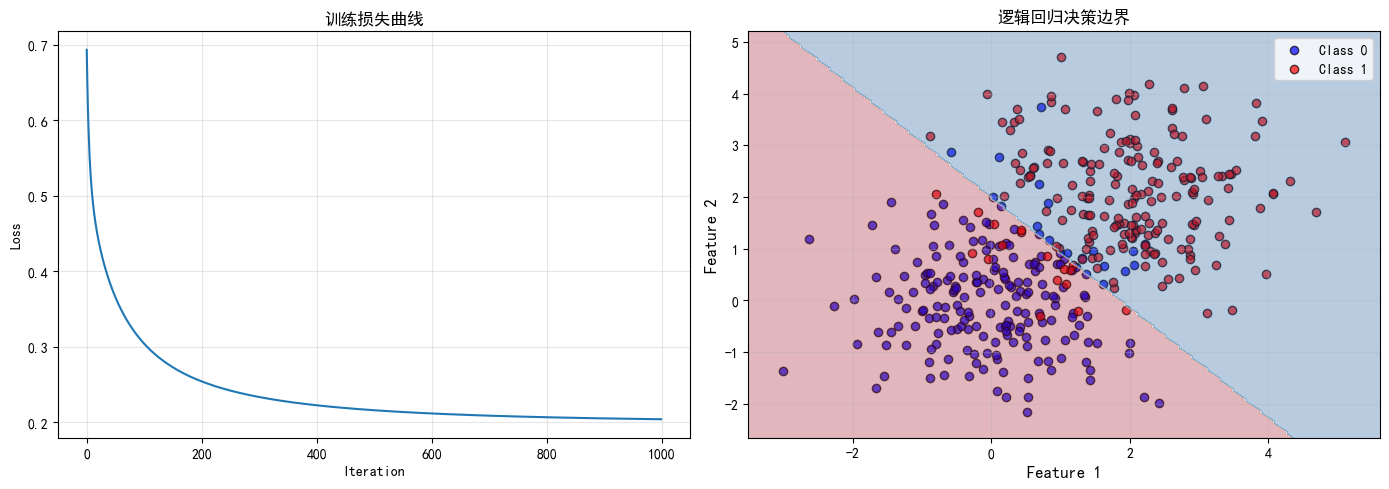

In [43]:
# 生成线性可分数据
np.random.seed(42)

def generate_data(n_samples=200, noise=0.1):
    # 类别0：以(0,0)为中心
    X0 = np.random.randn(n_samples//2, 2) + np.array([0, 0])
    y0 = np.zeros(n_samples//2)
    
    # 类别1：以(2,2)为中心
    X1 = np.random.randn(n_samples//2, 2) + np.array([2, 2])
    y1 = np.ones(n_samples//2)
    
    X = np.vstack([X0, X1])
    y = np.hstack([y0, y1])
    
    # 添加噪声
    X += np.random.randn(n_samples, 2) * noise
    
    return X, y

# 生成训练和测试数据
X_train, y_train = generate_data(400, noise=0.2)
X_test, y_test = generate_data(200, noise=0.2)

print(f"训练集大小: {X_train.shape}, 测试集大小: {X_test.shape}")

# Sigmoid函数
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 二元交叉熵损失
def binary_cross_entropy(y_pred, y_true):
    eps = 1e-8
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# 逻辑回归模型
class LogisticRegression:
    def __init__(self, learning_rate=0.1, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.W = None
        self.b = None
        self.losses = []
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.W = np.zeros(n_features)
        self.b = 0
        
        for i in range(self.n_iterations):
            # 前向传播
            linear_model = np.dot(X, self.W) + self.b
            y_pred = sigmoid(linear_model)
            
            # 计算损失
            loss = binary_cross_entropy(y_pred, y)
            self.losses.append(loss)
            
            # 计算梯度
            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            db = (1/n_samples) * np.sum(y_pred - y)
            
            # 更新参数
            self.W -= self.lr * dw
            self.b -= self.lr * db
            
            if (i + 1) % 200 == 0:
                print(f"Iteration {i+1}/{self.n_iterations}, Loss: {loss:.6f}")
    
    def predict_proba(self, X):
        linear_model = np.dot(X, self.W) + self.b
        return sigmoid(linear_model)
    
    def predict(self, X, threshold=0.5):
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)

# 训练模型
model = LogisticRegression(learning_rate=0.1, n_iterations=1000)
print("\n开始训练逻辑回归模型...")
model.fit(X_train, y_train)

# 预测
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_accuracy = np.mean(y_train_pred == y_train)
test_accuracy = np.mean(y_test_pred == y_test)

print(f"\n训练集准确率: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"测试集准确率: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# 绘制决策边界
def plot_decision_boundary(X, y, model):
    plt.figure(figsize=(10, 8))
    
    # 绘制数据点
    plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', label='Class 0', alpha=0.7, edgecolors='k')
    plt.scatter(X[y==1, 0], X[y==1, 1], c='red', label='Class 1', alpha=0.7, edgecolors='k')
    
    # 绘制决策边界
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.colorbar()
    
    plt.xlabel('Feature 1', fontsize=12)
    plt.ylabel('Feature 2', fontsize=12)
    plt.title('逻辑回归决策边界', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('logistic_regression_boundary.png', dpi=150)
    plt.show()

# 绘制损失曲线和决策边界
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 损失曲线
axes[0].plot(model.losses)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].set_title('训练损失曲线')
axes[0].grid(True, alpha=0.3)

# 决策边界（在训练集上）
axes[1].scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], c='blue', label='Class 0', alpha=0.7, edgecolors='k')
axes[1].scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], c='red', label='Class 1', alpha=0.7, edgecolors='k')

x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

axes[1].contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
axes[1].set_xlabel('Feature 1', fontsize=12)
axes[1].set_ylabel('Feature 2', fontsize=12)
axes[1].set_title('逻辑回归决策边界')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('logistic_regression_results.png', dpi=150)
plt.show()

